# 📉 B2B SaaS Churn — Exploratory Data Analysis
### A CSM → PM transition project

As a **Customer Success Manager**, I manually monitored accounts and metrics to determine when a customer would churn. This analysis is me putting on a **Product Manager**
hat and asking a different question: **what in the data should change what we build?**

The sections in this notebook identify what the product implication of the metrics are, not just the statistic. The goal is a short list of decisions a product team could actually act on.

> **Data:** `data/raw/saas_churn.csv` — 8,000 synthetic mid-market B2B SaaS accounts.
> Synthetic, but engineered to mirror real churn dynamics (usage, engagement, contract, tenure).

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# Consistent colors: blue = retained, red = churned
RETAINED, CHURNED = "#4C72B0", "#C44E52"
CHURN_PALETTE = {0: RETAINED, 1: CHURNED}

# Resolve paths whether this runs from the repo root or from notebooks/
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_PATH = ROOT / "data" / "raw" / "saas_churn.csv"
PLOTS_DIR = ROOT / "docs" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df):,} accounts x {df.shape[1]} columns")
df.head()

Loaded 8,000 accounts x 25 columns


,account_id,company_name,company_size,industry,contract_type,acv_usd,tenure_months,seats_purchased,seats_active_last_30d,seat_utilization_rate,...,support_tickets_last_90d,critical_tickets_last_90d,nps_score,qbr_attendance_rate,exec_sponsor_changed_last_180d,days_since_last_login,discount_pct,payment_delays_last_year,expansion_revenue_last_year_usd,churned
0,cb58dadc-b32f-46b9-8d20-5d782ffc2486,"Washington, Mccullough and Mccarthy",960,Telecom,Multi-year,12300,19,355,175,0.493,...,5,0,NaN,0.80,False,1,6.3,0,0,0
1,d11263af-5481-4cec-83f2-18614896a45c,Gonzalez Inc,2591,Tech,Annual,89765,12,398,149,0.374,...,10,2,5.0,0.55,False,83,11.0,2,0,1
2,b24be6ef-cb80-4dcf-bc8f-9d1ba646fccb,Gonzales Inc,2534,Finance,Annual,149816,6,394,269,0.683,...,2,0,7.0,0.87,False,8,18.0,0,0,0
3,a6ab69b9-41aa-4b63-b35a-4fea9a54b3f7,Grant Group,405,Finance,Annual,37055,28,86,71,0.826,...,1,0,10.0,0.96,False,2,11.5,0,7420,0
4,3f160973-9653-46e6-9aee-3d8eb9e8fc4b,Foster-Mccormick,823,Retail,Monthly,79846,44,384,84,0.219,...,4,2,6.0,0.14,True,40,14.9,2,0,1


## 1. Data quality check

In [10]:
# Dtypes and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 25 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   account_id                       8000 non-null   object 
 1   company_name                     8000 non-null   object 
 2   company_size                     8000 non-null   int64  
 3   industry                         8000 non-null   object 
 4   contract_type                    8000 non-null   object 
 5   acv_usd                          8000 non-null   int64  
 6   tenure_months                    8000 non-null   int64  
 7   seats_purchased                  8000 non-null   int64  
 8   seats_active_last_30d            8000 non-null   int64  
 9   seat_utilization_rate            8000 non-null   float64
 10  logins_last_30d                  8000 non-null   int64  
 11  admin_logins_last_30d            8000 non-null   int64  
 12  features_adopted    

In [11]:
# Numeric summary — sanity-check ranges (no negative seats, rates in [0,1], etc.)
df.describe().T

,count,mean,std,min,25%,50%,75%,max
company_size,8000.0,1220.509125,1906.139058,50.0,314.000,648.000,1380.250,50000.0
acv_usd,8000.0,72621.565500,65892.939936,5000.0,31944.500,53444.500,89786.250,894507.0
tenure_months,8000.0,27.578625,19.114621,1.0,13.000,23.000,37.000,120.0
seats_purchased,8000.0,337.132750,575.517223,5.0,70.000,158.000,369.000,12314.0
seats_active_last_30d,8000.0,182.122250,338.065588,0.0,32.000,80.000,195.250,7850.0
seat_utilization_rate,8000.0,0.547068,0.212682,0.0,0.403,0.547,0.695,1.0
logins_last_30d,8000.0,1661.779375,3876.136289,0.0,143.000,526.000,1580.500,111356.0
admin_logins_last_30d,8000.0,99.837000,233.519172,0.0,8.000,31.000,96.000,6727.0
features_adopted,8000.0,5.958875,3.151297,0.0,4.000,6.000,8.000,12.0
mfa_enabled_pct,8000.0,48.588538,23.577384,0.0,32.000,48.100,64.700,100.0


In [12]:
# Missing values
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Columns with missing values:")
if len(missing):
    for col in missing.index:
        print(f"  {col}: {missing[col]:,} ({missing[col] / len(df):.1%})")
else:
    print("  none")

# Duplicate accounts?
print(f"\nDuplicate account_ids: {df['account_id'].duplicated().sum()}")

# Logical-consistency checks a PM would care about
checks = {
    "active seats > purchased seats": (df["seats_active_last_30d"] > df["seats_purchased"]).sum(),
    "critical tickets > total tickets": (df["critical_tickets_last_90d"] > df["support_tickets_last_90d"]).sum(),
    "seat utilization > 100%": (df["seat_utilization_rate"] > 1).sum(),
    "admin logins > total logins": (df["admin_logins_last_30d"] > df["logins_last_30d"]).sum(),
}
print("\nConsistency checks (rows violating):")
for k, v in checks.items():
    print(f"  {k}: {v}")

Columns with missing values:
  nps_score: 1,599 (20.0%)

Duplicate account_ids: 0

Consistency checks (rows violating):
  active seats > purchased seats: 0
  critical tickets > total tickets: 0
  seat utilization > 100%: 0
  admin logins > total logins: 0



- **`nps_score` is ~20% missing.** 
  NPS is collected through surveys, but behavioral telemetry (logins, utilization) is complete for every
  account and is the more reliable foundation.
- **No duplicate accounts and no logical inconsistencies** (utilization ≤ 100%, criticals ≤ total
  tickets, etc.) — the usage instrumentation is internally coherent and safe to model on.

## 2. Churn rate analysis

Examining where churn is actually concentrated to determine where product can actually be developed.

In [13]:
overall = df["churned"].mean()
print(f"Overall churn rate: {overall:.1%}  ({df['churned'].sum():,} of {len(df):,} accounts)")

Overall churn rate: 20.1%  (1,611 of 8,000 accounts)


In [14]:
def churn_rate_by(col, order=None, title=None, fname=None, rotate=0):
    # Bar chart of churn rate (%) by a categorical column, vs the overall baseline.
    rates = df.groupby(col, observed=True)["churned"].mean().mul(100)
    rates = rates.reindex(order) if order is not None else rates.sort_values()
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, color=CHURNED)
    ax.axhline(overall * 100, ls="--", color="#2C3E50", lw=1.5,
               label=f"Overall ({overall:.0%})")
    for i, v in enumerate(rates.values):
        ax.text(i, v + 0.6, f"{v:.1f}%", ha="center", fontsize=10)
    ax.set_title(title or f"Churn rate by {col}", fontsize=13, weight="bold")
    ax.set_xlabel(col.replace("_", " ").title())
    ax.set_ylabel("Churn rate (%)")
    ax.legend()
    plt.xticks(rotation=rotate, ha="right" if rotate else "center")
    plt.tight_layout()
    if fname:
        fig.savefig(PLOTS_DIR / fname, dpi=120, bbox_inches="tight")
    plt.show()
    return rates

# Company-size buckets (employees)
size_bins = [0, 250, 1000, 5000, 100_000]
size_labels = ["SMB (<250)", "Mid-Market (250-1k)", "Enterprise (1k-5k)", "Strategic (5k+)"]
df["company_size_bucket"] = pd.cut(df["company_size"], bins=size_bins, labels=size_labels)

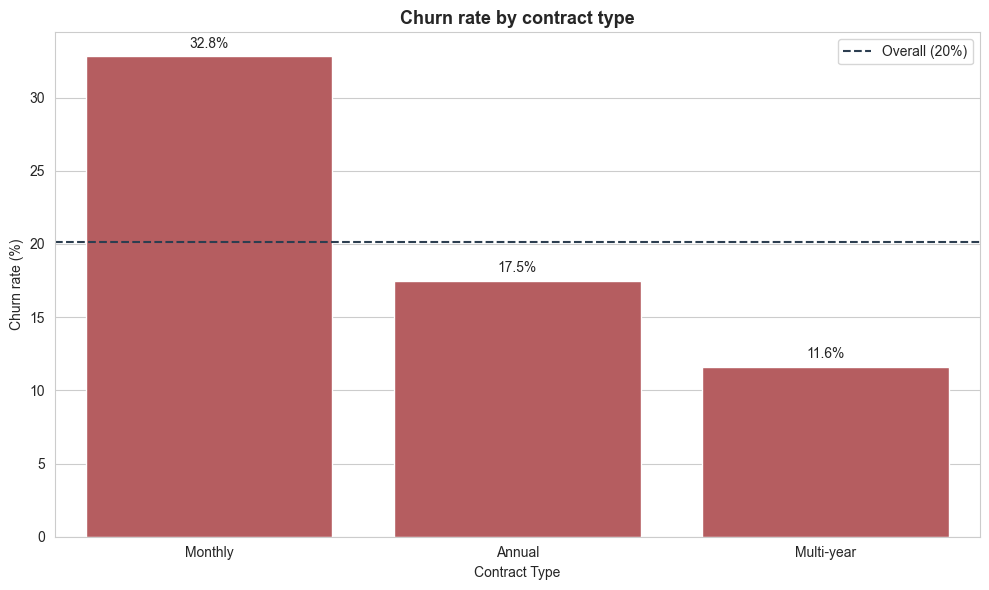

In [15]:
_ = churn_rate_by("contract_type", order=["Monthly", "Annual", "Multi-year"],
                  title="Churn rate by contract type", fname="churn_by_contract.png")

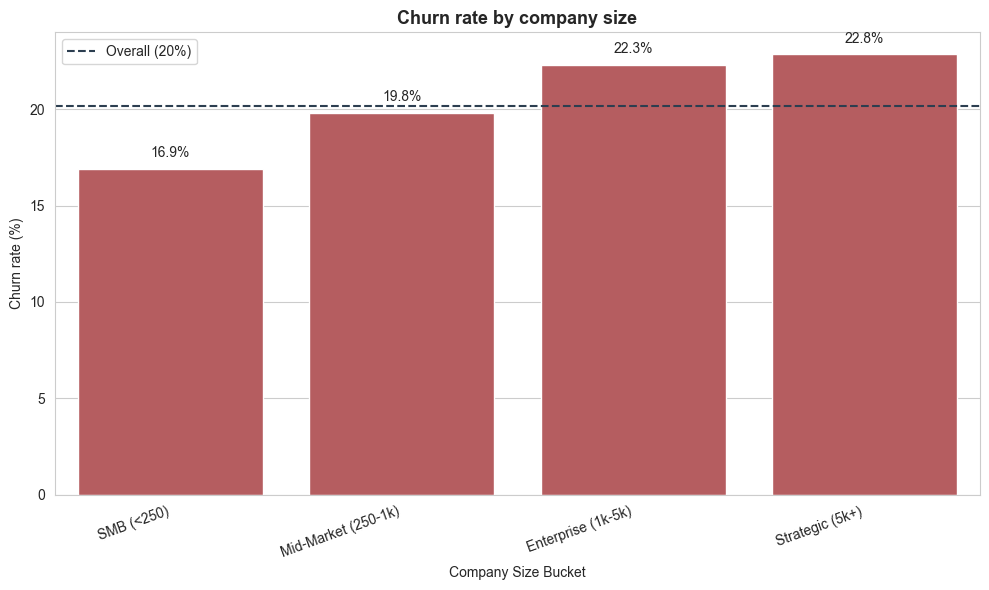

In [16]:
_ = churn_rate_by("company_size_bucket", order=size_labels,
                  title="Churn rate by company size", fname="churn_by_company_size.png", rotate=20)

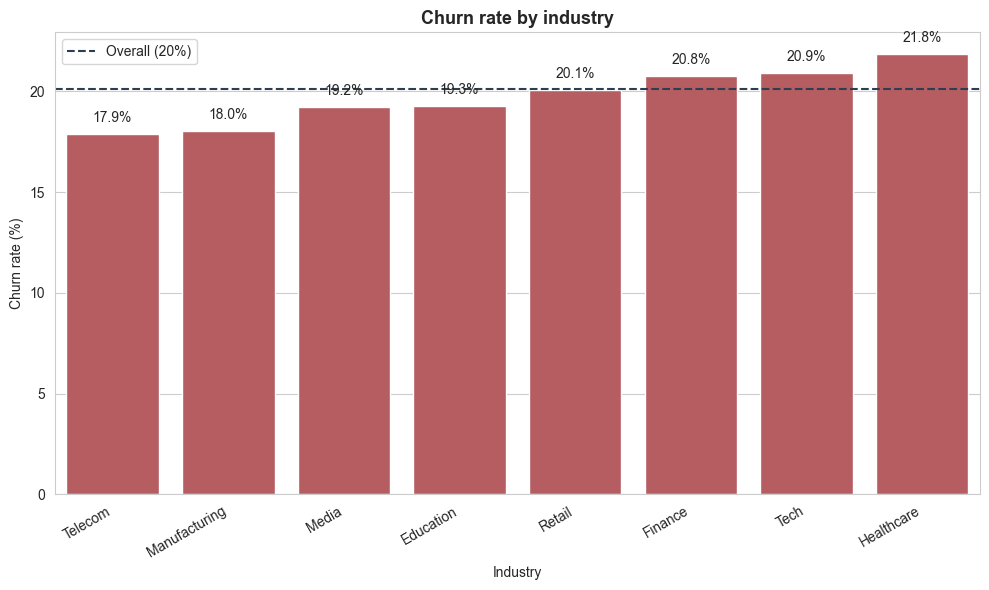

In [17]:
_ = churn_rate_by("industry", title="Churn rate by industry",
                  fname="churn_by_industry.png", rotate=30)


- **Contract type is the single biggest commercial lever.** Monthly contracts churn at
  ~33% vs ~12% for multi-year — nearly **3×**. This presents opportunity to change packaging.
- **Industry is essentially flat (~18–22%).** Industry is *not* a useful churn-targeting axis —
  resist the urge to build industry-specific playbooks for churn.

## 3. Behavioral signals 

Behavioral signals will indicate where the product can actually move.

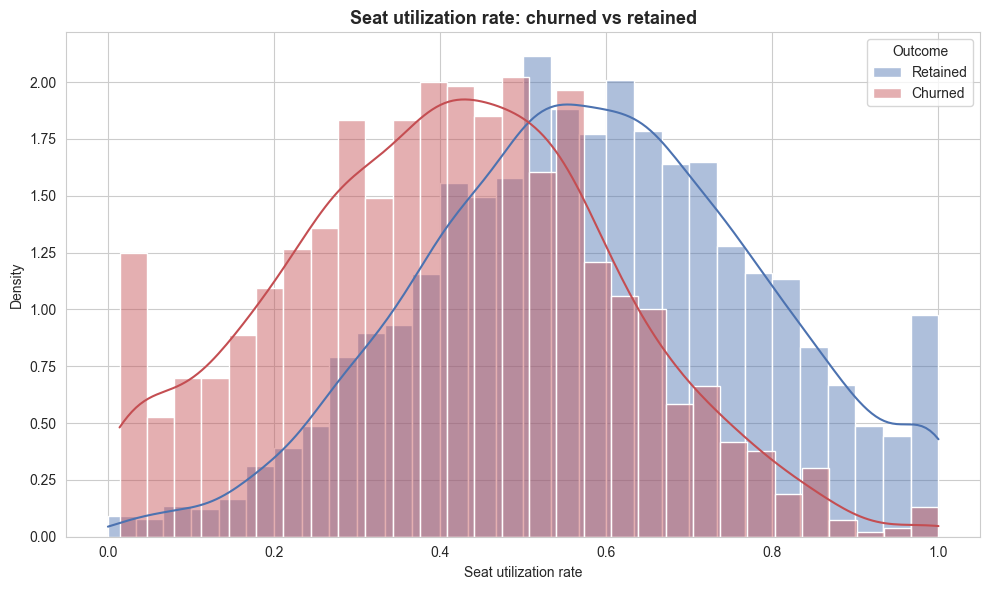

Mean utilization — churned: 0.41 | retained: 0.58


In [18]:
# Seat utilization: churned vs retained (overlapping densities)
fig, ax = plt.subplots(figsize=(10, 6))
for grp, label, color in [(0, "Retained", RETAINED), (1, "Churned", CHURNED)]:
    sns.histplot(df.loc[df["churned"] == grp, "seat_utilization_rate"],
                 bins=30, stat="density", kde=True, color=color, label=label, alpha=0.45, ax=ax)
ax.set_title("Seat utilization rate: churned vs retained", fontsize=13, weight="bold")
ax.set_xlabel("Seat utilization rate")
ax.set_ylabel("Density")
ax.legend(title="Outcome")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "seat_utilization_by_churn.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Mean utilization — churned: {df[df.churned==1].seat_utilization_rate.mean():.2f} | "
      f"retained: {df[df.churned==0].seat_utilization_rate.mean():.2f}")

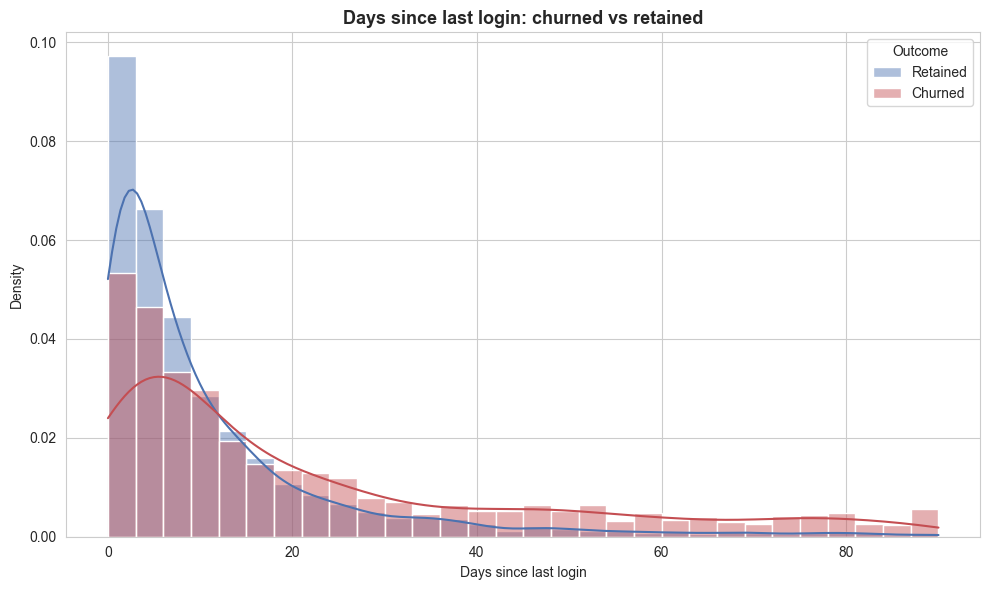

Mean days since login — churned: 22.2 | retained: 10.8


In [19]:
# Days since last login: churned vs retained
fig, ax = plt.subplots(figsize=(10, 6))
for grp, label, color in [(0, "Retained", RETAINED), (1, "Churned", CHURNED)]:
    sns.histplot(df.loc[df["churned"] == grp, "days_since_last_login"],
                 bins=30, stat="density", kde=True, color=color, label=label, alpha=0.45, ax=ax)
ax.set_title("Days since last login: churned vs retained", fontsize=13, weight="bold")
ax.set_xlabel("Days since last login")
ax.set_ylabel("Density")
ax.legend(title="Outcome")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "days_since_login_by_churn.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"Mean days since login — churned: {df[df.churned==1].days_since_last_login.mean():.1f} | "
      f"retained: {df[df.churned==0].days_since_last_login.mean():.1f}")

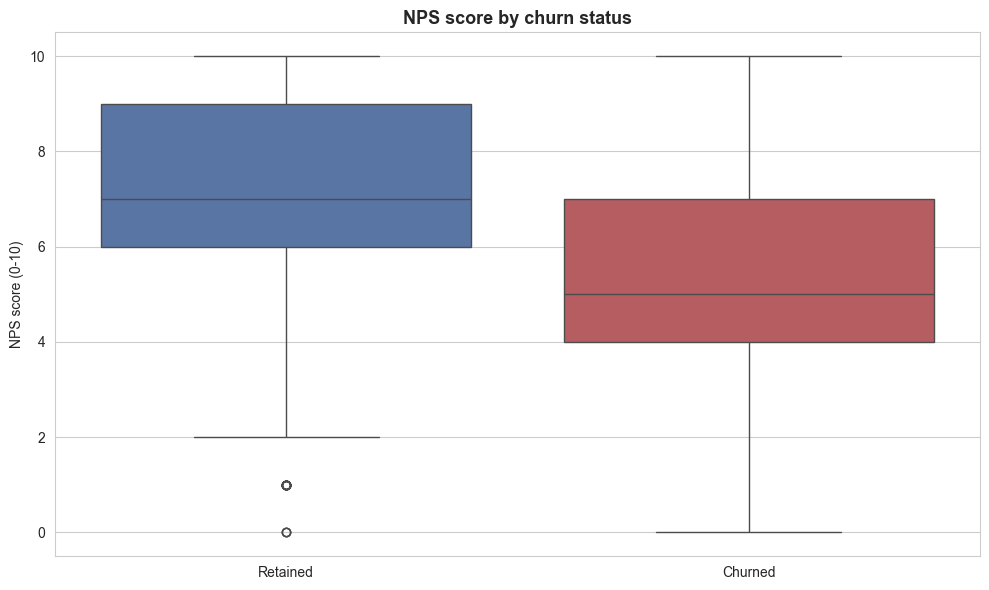

In [20]:
# NPS by churn status (box). NaNs are dropped automatically.
fig, ax = plt.subplots(figsize=(10, 6))
sns.boxplot(data=df, x="churned", y="nps_score", hue="churned",
            palette=CHURN_PALETTE, legend=False, ax=ax)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Retained", "Churned"])
ax.set_title("NPS score by churn status", fontsize=13, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("NPS score (0-10)")
plt.tight_layout()
fig.savefig(PLOTS_DIR / "nps_by_churn.png", dpi=120, bbox_inches="tight")
plt.show()

/var/folders/yl/c69n9q4d2z36lcfmfrhltlp00000gp/T/ipykernel_76259/1078239945.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["0", "1", "2", "3", "4+"])


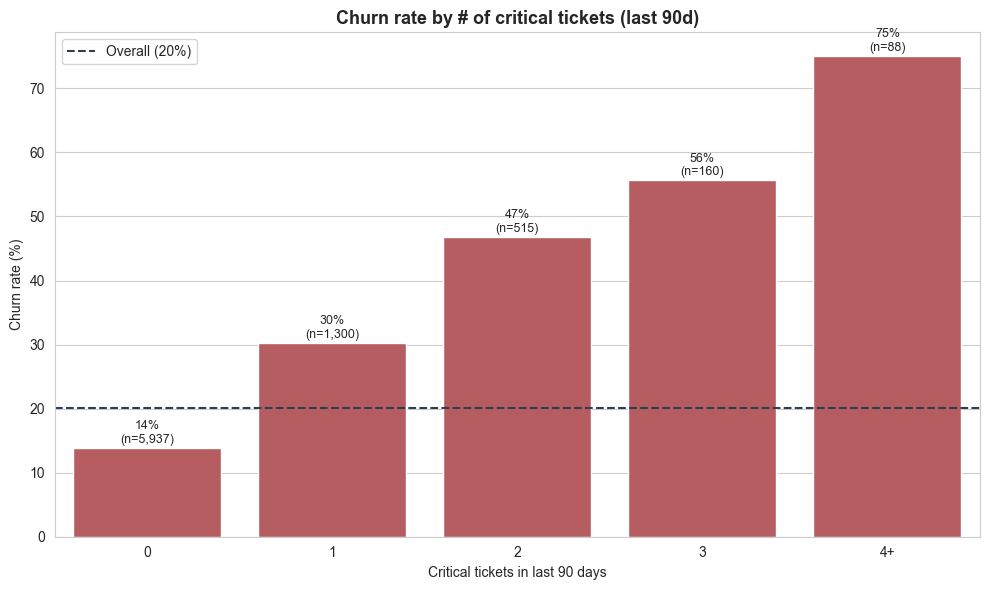

In [21]:
# Critical tickets vs churn rate
tmp = df.copy()
tmp["crit_bucket"] = tmp["critical_tickets_last_90d"].clip(upper=4)
rates = tmp.groupby("crit_bucket")["churned"].mean().mul(100)
counts = tmp.groupby("crit_bucket")["churned"].size()

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=rates.index, y=rates.values, ax=ax, color=CHURNED)
ax.axhline(overall * 100, ls="--", color="#2C3E50", lw=1.5, label=f"Overall ({overall:.0%})")
for i, (v, c) in enumerate(zip(rates.values, counts.values)):
    ax.text(i, v + 0.8, f"{v:.0f}%\n(n={c:,})", ha="center", fontsize=9)
ax.set_title("Churn rate by # of critical tickets (last 90d)", fontsize=13, weight="bold")
ax.set_xlabel("Critical tickets in last 90 days")
ax.set_ylabel("Churn rate (%)")
ax.set_xticklabels(["0", "1", "2", "3", "4+"])
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / "critical_tickets_churn.png", dpi=120, bbox_inches="tight")
plt.show()

**So what?**

- **Seat utilization is the clearest behavioral separator** (churned ≈ 0.41 vs retained ≈ 0.58). If there's low utilization of a product, value of the product is unrealized which puts the customer at risk for renewal. This means product should be geared towards encouraging seat activation so admins of the product can self correct before renewal.
- **Recency matters and is early.** Churned accounts average ~22 days since last login vs ~11 for
  retained. 
- **Critical tickets escalate churn sharply** — each additional critical ticket bends the curve up.
  **Implication:** a critical ticket should auto-trigger a CSM play, not just a support resolution.

## 4. Tenure analysis

When in the customer lifecycle is churn concentrated? If it's early, the fix is
onboarding/activation, where product teams can get the most benefit out of engaging.

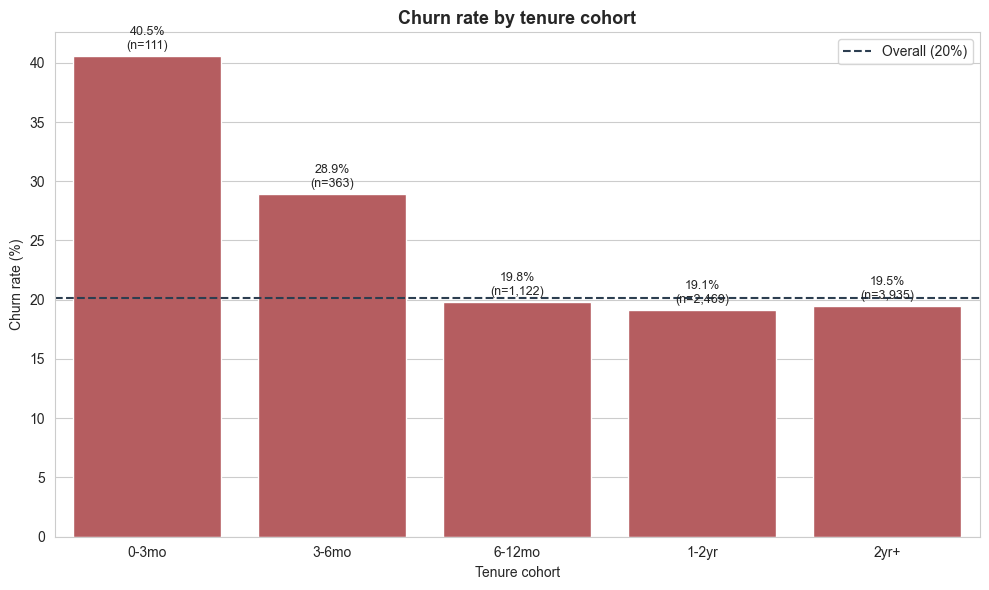

In [22]:
tenure_bins = [0, 3, 6, 12, 24, 10_000]
tenure_labels = ["0-3mo", "3-6mo", "6-12mo", "1-2yr", "2yr+"]
df["tenure_cohort"] = pd.cut(df["tenure_months"], bins=tenure_bins, labels=tenure_labels, right=False)

rates = df.groupby("tenure_cohort", observed=True)["churned"].mean().mul(100).reindex(tenure_labels)
counts = df.groupby("tenure_cohort", observed=True)["churned"].size().reindex(tenure_labels)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=rates.index.astype(str), y=rates.values, ax=ax, color=CHURNED)
ax.axhline(overall * 100, ls="--", color="#2C3E50", lw=1.5, label=f"Overall ({overall:.0%})")
for i, (v, c) in enumerate(zip(rates.values, counts.values)):
    ax.text(i, v + 0.6, f"{v:.1f}%\n(n={c:,})", ha="center", fontsize=9)
ax.set_title("Churn rate by tenure cohort", fontsize=13, weight="bold")
ax.set_xlabel("Tenure cohort")
ax.set_ylabel("Churn rate (%)")
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / "churn_by_tenure_cohort.png", dpi=120, bbox_inches="tight")
plt.show()

- **The first 3 months are a churn cliff (~40% vs ~20% baseline — roughly 2×), and risk
  normalizes after ~6 months.** Customers who don't reach value earlier tend to churn faster. 
- **Product implication:** the highest-ROI investment is **first-90-day activation**. Onboarding should be guided, there should be clear milestones, and early triggers should be activated for customers who haven't reached key activation events by day 30/60. 

## 5. Compound risk

This following section aims to answer if churn is driven by a single red flag or does it compound?

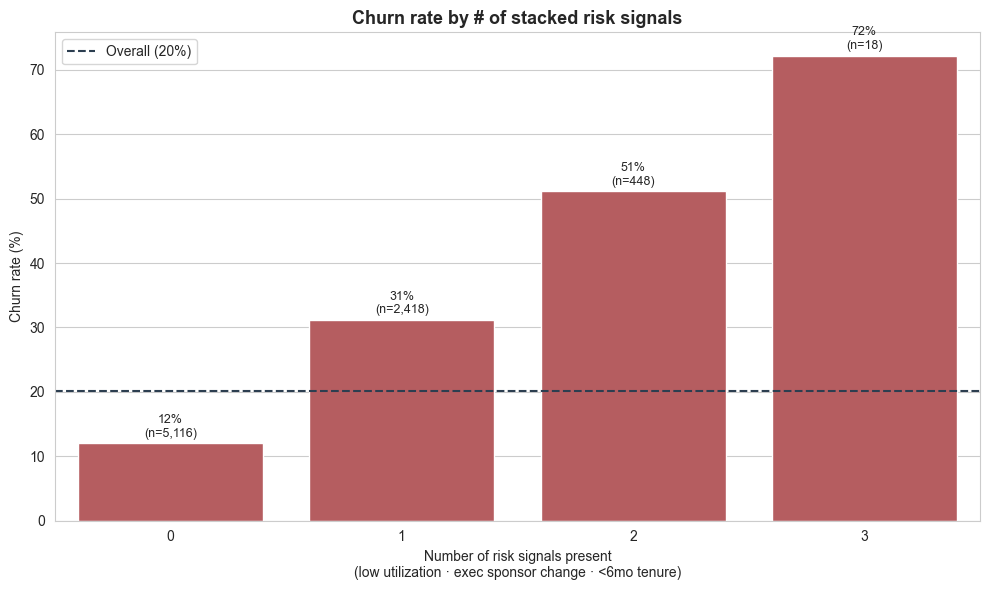

All three signals: n=18, churn rate = 72% (vs 20% baseline)


ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/noor.akhter/Desktop/churn-predictor/venv/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/noor.akhter/Desktop/churn-predictor/venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 302, in dispatch_control
    await self.process_control(msg)
  File "/Users/noor.akhter/Desktop/churn-predictor/venv/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 308, in process_control
    idents, msg = self.session.feed_identities(msg, copy=False)
  File "/Users/noor.akhter/Desktop/churn-predictor/venv/lib/python3.9/site-packages/jupyter_client/session.py", line 994, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/noor.akhter/Desktop/churn-predictor/venv/lib/python3.9/si

In [23]:
df["risk_low_util"] = (df["seat_utilization_rate"] < 0.4).astype(int)
df["risk_exec_change"] = df["exec_sponsor_changed_last_180d"].astype(int)
df["risk_short_tenure"] = (df["tenure_months"] < 6).astype(int)
df["risk_signal_count"] = df[["risk_low_util", "risk_exec_change", "risk_short_tenure"]].sum(axis=1)

comp = df.groupby("risk_signal_count")["churned"].agg(rate="mean", n="size")
comp["rate"] *= 100

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=comp.index, y=comp["rate"], ax=ax, color=CHURNED)
ax.axhline(overall * 100, ls="--", color="#2C3E50", lw=1.5, label=f"Overall ({overall:.0%})")
for i, (v, c) in enumerate(zip(comp["rate"], comp["n"])):
    ax.text(i, v + 1.0, f"{v:.0f}%\n(n={c:,})", ha="center", fontsize=9)
ax.set_title("Churn rate by # of stacked risk signals", fontsize=13, weight="bold")
ax.set_xlabel("Number of risk signals present\n(low utilization · exec sponsor change · <6mo tenure)")
ax.set_ylabel("Churn rate (%)")
ax.legend()
plt.tight_layout()
fig.savefig(PLOTS_DIR / "compound_risk.png", dpi=120, bbox_inches="tight")
plt.show()

triple = df[(df.risk_low_util == 1) & (df.risk_exec_change == 1) & (df.risk_short_tenure == 1)]
print(f"All three signals: n={len(triple)}, churn rate = {triple['churned'].mean():.0%} "
      f"(vs {overall:.0%} baseline)")



- **Risk compounds.** Churn climbs from ~12% with zero signals → ~31% (1) → ~51% (2) →
  ~72% (3). Signals are **more than additive** — each one roughly multiplies risk.
- **Product implication:** ship a **composite health score**, not a wall of single-metric alerts.
  Prioritize CSM capacity on the **2+ signal** accounts — that's where intervention ROI is highest.
- *(Caveat: the all-three segment is small (n≈18), so treat the exact 72% as directional, not precise.)*

## 6. Top 5 PM-relevant insights

Each is framed as **observation → product implication** — the handoff a product team can act on.

---

**1. The first 90 days are a churn cliff.**
*Observation:* 0–3mo accounts churn at ~40% vs ~20% baseline; risk normalizes after ~6 months.
*Product implication:* Make **first-90-day activation** the top retention investment — guided
onboarding, time-to-first-value milestones, and a day-30/60 alert for accounts that haven't activated.

---

**2. Contract structure is a ~3× churn lever.**
*Observation:* Monthly churns ~33% vs ~12% multi-year.
*Product implication:* Use **packaging/pricing incentives** to move customers off month-to-month,
and treat the remaining Monthly base as a standing watch-list with proactive nurture.

---

**3. Behavior beats firmographics.**
*Observation:* Churn is flat across industries (~18–22%) but varies sharply by usage (utilization
0.41 vs 0.58 churned/retained).
*Product implication:* Build health scoring on **behavioral telemetry**, not industry/segment.
Don't waste roadmap on industry-specific churn playbooks.

---

**4. Risk signals compound — so the score must too.**
*Observation:* Churn goes 12% → 31% → 51% → 72% as low-utilization, exec-sponsor-change, and
short-tenure signals stack.
*Product implication:* Ship a **composite, multi-signal health score** and route scarce CSM time to
**2+ signal** accounts, where save-rate ROI is highest.

---

**5. Don't anchor the product on NPS.**
*Observation:* NPS is ~20% missing (survey-dependent and biased), while logins/utilization are
complete for every account.
*Product implication:* Invest in **passive behavioral instrumentation** as the churn-signal backbone;
treat NPS as a nice-to-have enrichment, never a dependency.

---

*Next step: these insights feed directly into the churn model (`src/train.py`) and the
CSM-facing risk dashboard (`app/app.py`).*